# 03 — Feature selection, HPO, and ensemble analysis

実験終了後に、特徴量選択、HPO の探索履歴、モデル多様性、Hill Climbing の重みをまとめて確認します。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
results = pd.read_csv(ROOT / "results.csv")
results.sort_values("cv_accuracy", ascending=False)

,exp,model,feature_set,cv_strategy,cv_accuracy,cv_auc,memo
16,hill_climb_ensemble,hill_climb,oof_selected,stratified_group,0.821351,0.904913,Weights and threshold selected only from share...
1,exp101_catboost_baseline,catboost,basic,stratified_group,0.821235,0.904894,CatBoost native-categorical diverse baseline
6,exp201_catboost_selected,catboost,selected,stratified_group,0.819970,0.904335,CatBoost after group-CV feature-block selection
11,exp301_catboost_hpo,catboost,selected,stratified_group,0.816749,0.901044,HPO best trial 3; dedicated grouped tuning CV ...
2,exp102_xgboost_baseline,xgboost,basic,stratified_group,0.815024,0.903840,XGBoost one-hot diverse baseline
7,exp202_xgboost_selected,xgboost,selected,stratified_group,0.814794,0.903586,XGBoost after group-CV feature-block selection
12,exp302_xgboost_hpo,xgboost,selected,stratified_group,0.814794,0.903586,HPO best trial 0; dedicated grouped tuning CV ...
8,exp203_extratrees_selected,extratrees,selected,stratified_group,0.809272,0.891099,ExtraTrees after group-CV feature-block selection
3,exp103_extratrees_baseline,extratrees,basic,stratified_group,0.806626,0.887331,ExtraTrees diversity baseline
15,exp305_mlp_hpo,mlp,selected,stratified_group,0.806166,0.897505,HPO best trial 2; dedicated grouped tuning CV ...


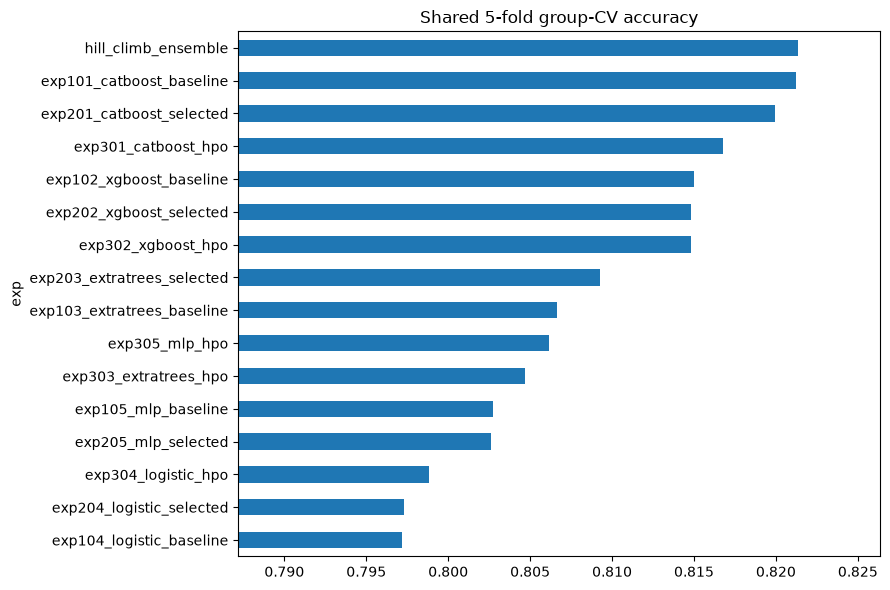

In [2]:
plot_results = results[results["cv_strategy"] == "stratified_group"].sort_values("cv_accuracy")
ax = plot_results.plot.barh(x="exp", y="cv_accuracy", figsize=(9, 6), legend=False)
ax.set_xlim(
    max(0.75, plot_results["cv_accuracy"].min() - 0.01), plot_results["cv_accuracy"].max() + 0.005
)
ax.set_title("Shared 5-fold group-CV accuracy")
plt.tight_layout()
plt.show()

## Feature-block selection
大量の個別候補を意味のある block にまとめ、greedy forward selection の全 trial を確認します。

In [3]:
feature_trials = pd.read_csv(ROOT / "artifacts/feature_selection.csv")
selected_blocks = yaml.safe_load((ROOT / "artifacts/selected_blocks.yaml").read_text())
display(feature_trials.sort_values(["round", "cv_accuracy"], ascending=[True, False]))
selected_blocks

,round,candidate,blocks,cv_accuracy,accepted
0,0,BASE,"cabin,group,age,spend_total,missing",0.804785,True
1,1,identity,"cabin,group,age,spend_total,missing,identity",0.805936,True
2,1,name,"cabin,group,age,spend_total,missing,name",0.803635,False
6,1,rules,"cabin,group,age,spend_total,missing,rules",0.803520,False
4,1,spend_ratio,"cabin,group,age,spend_total,missing,spend_ratio",0.803290,False
3,1,spend_log,"cabin,group,age,spend_total,missing,spend_log",0.802140,False
5,1,cross,"cabin,group,age,spend_total,missing,cross",0.801910,False
7,2,name,"cabin,group,age,spend_total,missing,identity,name",0.808237,True
11,2,rules,"cabin,group,age,spend_total,missing,identity,r...",0.806051,False
8,2,spend_log,"cabin,group,age,spend_total,missing,identity,s...",0.805476,False


{'selected_blocks': ['cabin',
  'group',
  'age',
  'spend_total',
  'missing',
  'identity',
  'name'],
 'selection_model': 'ExtraTreesClassifier',
 'cv_strategy': 'StratifiedGroupKFold',
 'cv_accuracy': 0.8082365121362015,
 'n_estimators': 160,
 'seed': 42}

## HPO audit
HPO は seed=2025 の専用 3-fold group CV で探索し、best config を seed=42 の固定 5-fold group CV で再評価します。探索 score と確認 score を混同しません。

In [4]:
hpo_rows = []
for path in sorted((ROOT / "artifacts/hpo").glob("*_trials.csv")):
    frame = pd.read_csv(path)
    completed = frame[frame["state"] == "COMPLETE"].copy()
    completed["model"] = path.stem.replace("_trials", "")
    completed["best_so_far"] = completed["value"].cummax()
    hpo_rows.append(completed)
hpo_trials = pd.concat(hpo_rows, ignore_index=True)
display(hpo_trials.groupby("model")["value"].agg(["count", "max", "mean", "std"]))

,count,max,mean,std
model,,,,
catboost,5,0.813068,0.812171,0.000706
extratrees,5,0.807431,0.804808,0.001701
logistic,5,0.799149,0.792086,0.008307
mlp,5,0.806741,0.802899,0.003798
xgboost,5,0.811457,0.806626,0.003703


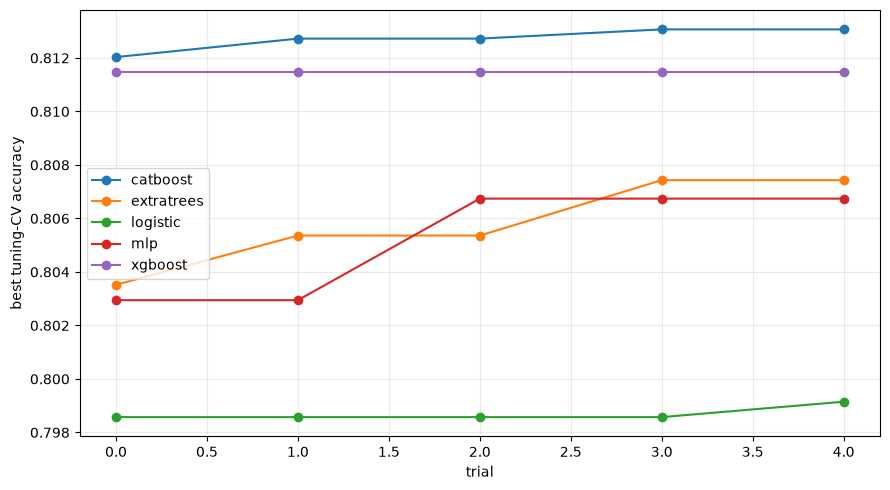

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for model, frame in hpo_trials.groupby("model"):
    ax.plot(frame["number"], frame["best_so_far"], marker="o", label=model)
ax.set_xlabel("trial")
ax.set_ylabel("best tuning-CV accuracy")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [6]:
best_payloads = [
    json.loads(path.read_text()) for path in sorted((ROOT / "artifacts/hpo").glob("*_best.json"))
]
pd.DataFrame(
    [
        {
            "model": item["model"],
            "best_trial": item["best_trial"],
            "tuning_cv_accuracy": item["tuning_cv_accuracy"],
            "tuning_seed": item["tuning_seed"],
        }
        for item in best_payloads
    ]
).sort_values("tuning_cv_accuracy", ascending=False)

,model,best_trial,tuning_cv_accuracy,tuning_seed
0,catboost,3,0.813068,2025
4,xgboost,0,0.811457,2025
1,extratrees,3,0.807431,2025
3,mlp,2,0.806741,2025
2,logistic,4,0.799149,2025


## OOF diversity and Hill Climbing
全候補は同じ5-fold assignment・同じ行順です。単体 score だけでなく OOF 相関と最終 weight を確認します。

In [7]:
ensemble_dir = ROOT / "output/hill_climb_ensemble"
correlations = pd.read_csv(ensemble_dir / "oof_correlations.csv", index_col=0)
weights = pd.read_csv(ensemble_dir / "weights.csv").sort_values("weight", ascending=False)
metrics = json.loads((ensemble_dir / "metrics.json").read_text())
display(correlations.round(3))
display(weights)
metrics

,exp101_catboost_baseline,exp102_xgboost_baseline,exp103_extratrees_baseline,exp104_logistic_baseline,exp105_mlp_baseline,exp201_catboost_selected,exp202_xgboost_selected,exp203_extratrees_selected,exp204_logistic_selected,exp205_mlp_selected,exp301_catboost_hpo,exp302_xgboost_hpo,exp303_extratrees_hpo,exp304_logistic_hpo,exp305_mlp_hpo
exp101_catboost_baseline,1.000,0.974,0.925,0.938,0.939,0.993,0.974,0.933,0.938,0.938,0.992,0.974,0.956,0.937,0.954
exp102_xgboost_baseline,0.974,1.000,0.934,0.931,0.945,0.973,0.995,0.941,0.931,0.936,0.968,0.995,0.958,0.934,0.954
exp103_extratrees_baseline,0.925,0.934,1.000,0.868,0.896,0.923,0.932,0.990,0.868,0.888,0.915,0.932,0.975,0.869,0.899
exp104_logistic_baseline,0.938,0.931,0.868,1.000,0.929,0.939,0.931,0.877,1.000,0.935,0.945,0.931,0.898,0.998,0.967
exp105_mlp_baseline,0.939,0.945,0.896,0.929,1.000,0.936,0.942,0.903,0.929,0.940,0.933,0.942,0.921,0.932,0.959
exp201_catboost_selected,0.993,0.973,0.923,0.939,0.936,1.000,0.974,0.933,0.939,0.937,0.993,0.974,0.956,0.937,0.954
exp202_xgboost_selected,0.974,0.995,0.932,0.931,0.942,0.974,1.000,0.941,0.931,0.937,0.969,1.000,0.958,0.933,0.954
exp203_extratrees_selected,0.933,0.941,0.990,0.877,0.903,0.933,0.941,1.000,0.877,0.897,0.925,0.941,0.984,0.878,0.908
exp204_logistic_selected,0.938,0.931,0.868,1.000,0.929,0.939,0.931,0.877,1.000,0.936,0.945,0.931,0.898,0.998,0.967
exp205_mlp_selected,0.938,0.936,0.888,0.935,0.940,0.937,0.937,0.897,0.936,1.000,0.937,0.937,0.916,0.936,0.960


,experiment,selections,weight
0,exp101_catboost_baseline,2,0.9915
5,exp201_catboost_selected,1,0.0085
1,exp102_xgboost_baseline,0,0.0000
2,exp103_extratrees_baseline,0,0.0000
3,exp104_logistic_baseline,0,0.0000
4,exp105_mlp_baseline,0,0.0000
6,exp202_xgboost_selected,0,0.0000
7,exp203_extratrees_selected,0,0.0000
8,exp204_logistic_selected,0,0.0000
9,exp205_mlp_selected,0,0.0000


{'accuracy': 0.8213505119061314,
 'roc_auc': 0.9049130620975943,
 'log_loss': 0.38260975080326953,
 'threshold': 0.5000000000000001,
 'weights': [{'experiment': 'exp101_catboost_baseline',
   'selections': 2,
   'weight': 0.9915},
  {'experiment': 'exp102_xgboost_baseline', 'selections': 0, 'weight': 0.0},
  {'experiment': 'exp103_extratrees_baseline', 'selections': 0, 'weight': 0.0},
  {'experiment': 'exp104_logistic_baseline', 'selections': 0, 'weight': 0.0},
  {'experiment': 'exp105_mlp_baseline', 'selections': 0, 'weight': 0.0},
  {'experiment': 'exp201_catboost_selected',
   'selections': 1,
   'weight': 0.0085},
  {'experiment': 'exp202_xgboost_selected', 'selections': 0, 'weight': 0.0},
  {'experiment': 'exp203_extratrees_selected', 'selections': 0, 'weight': 0.0},
  {'experiment': 'exp204_logistic_selected', 'selections': 0, 'weight': 0.0},
  {'experiment': 'exp205_mlp_selected', 'selections': 0, 'weight': 0.0},
  {'experiment': 'exp301_catboost_hpo', 'selections': 0, 'weight':

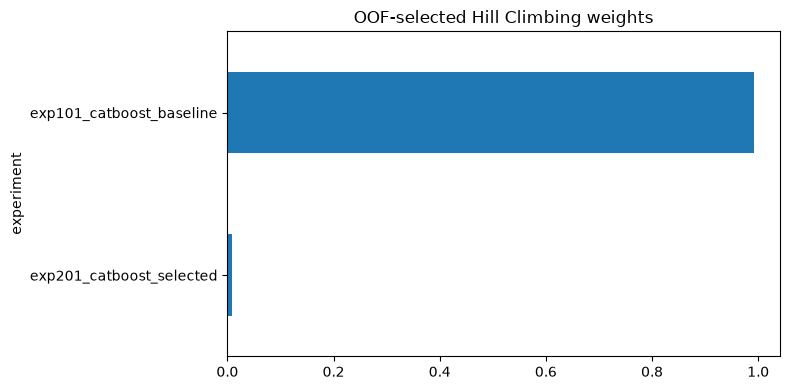

In [8]:
nonzero = weights[weights["weight"] > 0].sort_values("weight")
ax = nonzero.plot.barh(x="experiment", y="weight", legend=False, figsize=(8, 4))
ax.set_title("OOF-selected Hill Climbing weights")
plt.tight_layout()
plt.show()

## Transfer checklist for another competition
1. `target`, `id_column`, metric を置き換える。
2. データ生成単位から CV strategy/group/time を決め、fold を保存する。
3. competition-specific な候補だけを `features.py` に block として追加する。
4. 同じ fold で diverse baseline を作る。
5. feature selection 後、専用 tuning CV で HPO し、固定 confirmation CV で再評価する。
6. 同一行・同一 fold の OOF だけで ensemble weight と threshold を決める。
7. Public LB は最終的な sanity check として記録するだけにする。